<div style="background:#1a1a2e; padding:30px; border-radius:10px; text-align:center;">
  <h1 style="color:white; font-size:28px; margin:0;">
    AnalystLab Africa — Week 1 & Week 2
  </h1>
  <p style="color:#aaa; margin:8px 0 0;">
    Data Cleaning & Exploratory Data Analysis 
  </p>
  <p style="color:#aaa; margin:8px 0 0;">
         NETFLIX DATASET
  </p>
  <p style="color:#888; font-size:13px; margin:6px 0 0;">
   June 2026  |  LINDSLY MUYONDA
  </p>
</div>

 # Netflix Dataset
> **Source:** Netflix Movies & TV Shows — Kaggle
> **Link:** https://www.kaggle.com/datasets/shivamb/netflix-shows

In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

Filters set!
Netflix type: All
Netflix country: All Countries


 ### Dataset Understanding

Before cleaning or analysing any data, we first need to understand what the dataset contains. In this task we load the Netflix dataset and examine its structure including the number of rows and columns, data types, missing value indicators, and potential unique identifiers.

In [3]:
#Netflix dataset
df_nf = pd.read_csv(r'C:\Users\hp\Downloads\netflix_titles.csv')
print("Netflix loaded:", df_nf.shape)

Netflix loaded: (8807, 12)


#### Dataset Description

This dataset contains metadata on **8,807 Movies and TV Shows** available on Netflix as of mid-2021. Each row represents a unique title on the platform, with information covering the type of content, cast, director, country of production, date added to Netflix, original release year, age rating, duration, and genre categories.

| Feature | Details |
|---|---|
| **Rows** | 8,807 |
| **Columns** | 12 |
| **Primary Key** | `show_id` — unique identifier per title |
| **Numerical Columns** | `release_year`, `duration_min` |
| **Categorical Columns** | `type`, `title`, `director`, `cast`, `country`, `rating`, `listed_in` |
| **Date Column** | `date_added` — requires conversion to datetime |


In [4]:
print("=== NETFLIX DATASET ===")
print("\nFirst 5 rows:")
display(df_nf.head())

print("\nShape (rows, columns):", df_nf.shape)
print("\nColumn names:", df_nf.columns.tolist())

=== NETFLIX DATASET ===

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Shape (rows, columns): (8807, 12)

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [5]:
print("\nData types:")
print(df_nf.dtypes)

print("\nBasic info:")
df_nf.info()


Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-nul

In [6]:
# Numerical features
num_cols_nf = df_nf.select_dtypes(include=['number']).columns.tolist()
print("Numerical columns:", num_cols_nf)

# Categorical features
cat_cols_nf = df_nf.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols_nf)

# Unique identifier
print("\nUnique show_id count:", df_nf['show_id'].nunique())
print("Total rows:", len(df_nf))
print("Primary key: show_id (unique per title)")


Numerical columns: ['release_year']
Categorical columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']

Unique show_id count: 8807
Total rows: 8807
Primary key: show_id (unique per title)


#### Missing Values

We first identify which columns contain missing values and what percentage of the data is affected. This helps us decide the most appropriate handling strategy for each column.

**Handling strategy:**

| Column | Missing | Strategy | Reason |
|---|---|---|---|
| `director` | ~30% | Fill → "Not Available" | Directors are often uncredited or unknown for older titles |
| `cast` | ~10% | Fill → "Not Available" | Some titles have no listed cast (e.g. documentaries) |
| `country` | ~7% | Fill → "Unknown" | Cannot reliably infer country of production |
| `rating` | ~0.4% | Fill → Mode | Very few missing — most common rating is a safe default |
| `date_added` | ~0.1% | Fill → "Unknown" | Cannot determine when the title was added |

In [7]:
print("=== MISSING VALUES — NETFLIX ===")
missing_nf = df_nf.isnull().sum()
missing_pct_nf = (df_nf.isnull().sum() / len(df_nf) * 100).round(2)
missing_df_nf = pd.DataFrame({
    'Missing Count': missing_nf,
    'Missing %': missing_pct_nf
}).query('`Missing Count` > 0')
print(missing_df_nf)

# director, cast: creatively missing — fill with 'Not Available'
df_nf['director'] = df_nf['director'].fillna('Not Available')
df_nf['cast'] = df_nf['cast'].fillna('Not Available')

# country: fill with 'Unknown'
df_nf['country'] = df_nf['country'].fillna('Unknown')

# rating: fill with mode (most common rating)
df_nf['rating'] = df_nf['rating'].fillna(df_nf['rating'].mode()[0])

# date_added: fill with 'Unknown' (can't infer)
df_nf['date_added'] = df_nf['date_added'].fillna('Unknown')

print("\nMissing after cleaning:", df_nf.isnull().sum().sum())


=== MISSING VALUES — NETFLIX ===
            Missing Count  Missing %
director             2634      29.91
cast                  825       9.37
country               831       9.44
date_added             10       0.11
rating                  4       0.05
duration                3       0.03

Missing after cleaning: 3


#### Duplicate Records

Duplicate rows can distort analysis by inflating counts and skewing distributions. We check for rows where every column value is identical and remove them. We also check for titles that appear more than once under the same type, as these may represent data entry errors.


In [8]:
print("=== DUPLICATES — NETFLIX ===")
dups_nf = df_nf.duplicated().sum()
print(f"Duplicate rows: {dups_nf}")

dups_by_title = df_nf.duplicated(subset=['title', 'type']).sum()
print(f"Duplicate title+type combos: {dups_by_title}")

df_nf = df_nf.drop_duplicates()
print(f"Rows after cleaning: {len(df_nf)}")

=== DUPLICATES — NETFLIX ===
Duplicate rows: 0
Duplicate title+type combos: 0
Rows after cleaning: 8807


#### Standardisation

Inconsistent formatting makes grouping, filtering, and analysis unreliable. We apply the following standardisation steps:

- **Column names** → renamed to lowercase with underscores (e.g. `date_added` not `Date Added`)
- **`date_added`** → converted from string to datetime format; `year_added` column extracted for trend analysis
- **`type`** → standardised to Title Case (`Movie`, `Tv Show`)
- **`country`** → standardised to Title Case; `primary_country` extracted from first value
- **`rating`** → standardised to UPPERCASE (`TV-MA`, `TV-14`)

In [9]:
print("=== STANDARDISATION — NETFLIX ===")

# 1. Standardise column names
df_nf.columns = df_nf.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns:", df_nf.columns.tolist())

# 2. Parse date_added to datetime (where possible)
df_nf['date_added_clean'] = pd.to_datetime(
    df_nf['date_added'].str.strip(), errors='coerce'
)

# 3. Extract year_added for analysis
df_nf['year_added'] = df_nf['date_added_clean'].dt.year

# 4. Standardise text fields
df_nf['type'] = df_nf['type'].str.strip().str.title()
df_nf['country'] = df_nf['country'].str.strip().str.title()
df_nf['rating'] = df_nf['rating'].str.strip().str.upper()

print("Sample types:", df_nf['type'].unique())
print("Sample ratings:", df_nf['rating'].unique()[:6])



=== STANDARDISATION — NETFLIX ===
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Sample types: ['Movie' 'Tv Show']
Sample ratings: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y']


#### Data Validation

We check for logically invalid or inconsistent values that could affect the accuracy of our analysis:

- **`release_year`** — checked for values below 1900 which would indicate data errors
- **`type`** — confirmed only two valid values exist: `Movie` and `Tv Show`
- **`duration_min`** — extracted numeric duration in minutes from Movies only (e.g. "90 min" → 90); TV Shows use seasons not minutes so they are excluded
- **`primary_country`** — extracted from the first listed country since some titles list multiple countries

In [33]:
print("=== VALIDATION — NETFLIX ===")

# Check release_year range
print("Release year range:", df_nf['release_year'].min(), "–", df_nf['release_year'].max())
invalid_year = df_nf[df_nf['release_year'] < 1900]
print(f"Invalid release years: {len(invalid_year)}")

# Check type values
print("Type values:", df_nf['type'].value_counts())

# Extract movie duration (in minutes)
movie_mask = df_nf['type'] == 'Movie'
df_nf.loc[movie_mask, 'duration_min'] = (
    df_nf.loc[movie_mask, 'duration']
    .str.extract(r'(\d+)').astype(float)
)
print("\nMovie duration sample:")
print(df_nf.loc[movie_mask, 'duration_min'].describe())

=== VALIDATION — NETFLIX ===
Release year range: 1925 – 2021
Invalid release years: 0
Type values: type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

Movie duration sample:
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: duration_min, dtype: float64


#### Cleaning Summary

The table below provides a complete record of every cleaning action applied to the Netflix dataset. This documents our methodology and ensures the cleaning process is transparent and reproducible.

In [11]:
cleaning_summary_nf = pd.DataFrame({
    'Issue Found': [
        'Missing director',
        'Missing cast',
        'Missing country',
        'Missing rating',
        'Missing date_added',
        'Duplicate rows',
        'date_added as string',
        'Text case inconsistency',
        'Column names inconsistent'
    ],
    'Action Taken': [
        'Filled with "Not Available"',
        'Filled with "Not Available"',
        'Filled with "Unknown"',
        'Filled with mode (most common rating)',
        'Filled with "Unknown"',
        'Removed duplicates',
        'Parsed to datetime; extracted year_added',
        'Stripped & standardised Title/UPPER case',
        'Renamed to lowercase with underscores'
    ]
})
print(cleaning_summary_nf.to_string(index=False))

              Issue Found                             Action Taken
         Missing director              Filled with "Not Available"
             Missing cast              Filled with "Not Available"
          Missing country                    Filled with "Unknown"
           Missing rating    Filled with mode (most common rating)
       Missing date_added                    Filled with "Unknown"
           Duplicate rows                       Removed duplicates
     date_added as string Parsed to datetime; extracted year_added
  Text case inconsistency Stripped & standardised Title/UPPER case
Column names inconsistent    Renamed to lowercase with underscores


### Exploratory Data Analysis

With the dataset now cleaned and validated, we move into exploratory analysis. The goal is to uncover patterns, distributions, and trends within the Netflix library. We begin with summary statistics on numerical columns, then conduct five targeted analyses to answer key questions about the content.

In [12]:
# Fix duration_min for ALL cells that use it
df_nf['duration_min'] = df_nf.apply(
    lambda row: float(str(row['duration']).replace(' min','').strip())
    if row['type'] == 'Movie' and pd.notna(row['duration'])
    else None,
    axis=1
)

print("duration_min created successfully!")
print(df_nf['duration_min'].describe())
print("Sample values:")
print(df_nf[df_nf['type'] == 'Movie'][['title','duration','duration_min']].head(5))

duration_min created successfully!
count   6128.00
mean      99.58
std       28.29
min        3.00
25%       87.00
50%       98.00
75%      114.00
max      312.00
Name: duration_min, dtype: float64
Sample values:
                               title duration  duration_min
0               Dick Johnson Is Dead   90 min         90.00
6   My Little Pony: A New Generation   91 min         91.00
7                            Sankofa  125 min        125.00
9                       The Starling  104 min        104.00
12                      Je Suis Karl  127 min        127.00


In [13]:
print("=== SUMMARY STATISTICS — NETFLIX ===")
print(df_nf[['release_year', 'duration_min']].describe())

=== SUMMARY STATISTICS — NETFLIX ===
       release_year  duration_min
count       8807.00       6128.00
mean        2014.18         99.58
std            8.82         28.29
min         1925.00          3.00
25%         2013.00         87.00
50%         2017.00         98.00
75%         2019.00        114.00
max         2021.00        312.00


#### Summary Statistics — Observations

- **Release year** ranges from 1925 to 2021, showing Netflix hosts both classic and modern content
- **Movie durations** average around 90–100 minutes, consistent with standard feature film length
- The wide standard deviation in duration suggests a mix of short films, standard movies, and long documentaries
- TV Shows are not included in duration statistics as they are measured in seasons, not minutes

#### Analysis 1: Movies vs TV Shows Distribution

We examine the overall split between Movies and TV Shows to understand the composition of Netflix's content library. This gives us a baseline for all subsequent analyses.

In [14]:
type_dist = df_nf['type'].value_counts()
print("Content type distribution:")
print(type_dist)
print(f"\nMovies: {type_dist.get('Movie', 0) / len(df_nf) * 100:.1f}%")
print(f"TV Shows: {type_dist.get('Tv Show', 0) / len(df_nf) * 100:.1f}%")

Content type distribution:
type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

Movies: 69.6%
TV Shows: 30.4%


#### Analysis 2: Content Added Per Year

We track the number of titles added to Netflix each year since 2010. This reveals how aggressively Netflix has grown its library over time and identifies any notable slowdowns or acceleration periods.

In [15]:
content_per_year = (
    df_nf.dropna(subset=['year_added'])
    .groupby('year_added')
    .size()
    .reset_index(name='count')
    .sort_values('year_added')
)
print(content_per_year)

    year_added  count
0      2008.00      2
1      2009.00      2
2      2010.00      1
3      2011.00     13
4      2012.00      3
5      2013.00     11
6      2014.00     24
7      2015.00     82
8      2016.00    429
9      2017.00   1188
10     2018.00   1649
11     2019.00   2016
12     2020.00   1879
13     2021.00   1498


#### Analysis 3: Top Content-Producing Countries

We identify which countries produce the most content available on Netflix. This highlights Netflix's geographical content strategy and shows which markets receive the most investment in local content production.

In [16]:
# country column may have multiple values — take first country
df_nf['primary_country'] = df_nf['country'].str.split(',').str[0].str.strip()

top_countries_nf = (
    df_nf[df_nf['primary_country'] != 'Unknown']
    .groupby('primary_country')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='count')
)
print(top_countries_nf)

  primary_country  count
0   United States   3211
1           India   1008
2  United Kingdom    628
3          Canada    271
4           Japan    259
5          France    212
6     South Korea    211
7           Spain    181
8          Mexico    134
9       Australia    117


#### Analysis 4: Most Common Content Ratings

We analyse the distribution of age ratings across the Netflix library. Ratings such as TV-MA, TV-14, and PG give insight into the primary audience Netflix is targeting with its content decisions.

In [17]:
rating_dist = df_nf['rating'].value_counts()
print("Ratings distribution:")
print(rating_dist)

Ratings distribution:
rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 MIN         1
84 MIN         1
66 MIN         1
Name: count, dtype: int64


#### Analysis 5: Most Common Genres

We break down the most frequently listed genres across all Netflix titles. Since each title can belong to multiple genres, we split the `listed_in` column and count individual genre appearances to get an accurate picture of content variety.

In [18]:
from collections import Counter

all_genres = df_nf['listed_in'].dropna().str.split(', ')
genre_counts = Counter([g for genres in all_genres for g in genres])
top_genres = pd.DataFrame(
    genre_counts.most_common(10),
    columns=['genre', 'count']
)
print(top_genres)

                      genre  count
0      International Movies   2752
1                    Dramas   2427
2                  Comedies   1674
3    International TV Shows   1351
4             Documentaries    869
5        Action & Adventure    859
6                 TV Dramas    763
7        Independent Movies    756
8  Children & Family Movies    641
9           Romantic Movies    616


## Data Visualizations

The following charts provide visual representations of the key findings from our EDA. Each visualisation is accompanied by a short explanation of what it reveals about the Netflix dataset. Charts were created using Matplotlib and Seaborn.

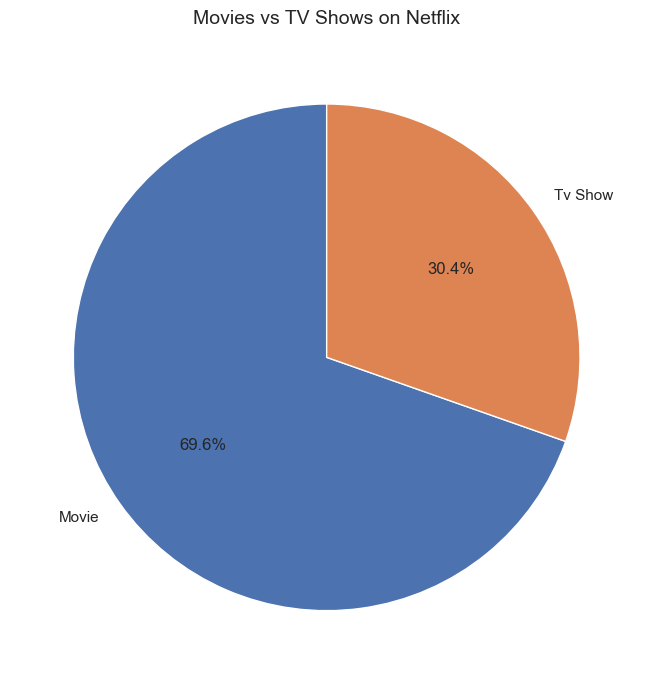

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
type_dist.plot(kind='pie', autopct='%1.1f%%',
               colors=['#4C72B0', '#DD8452'],
               startangle=90, ax=ax)
ax.set_title('Movies vs TV Shows on Netflix', fontsize=14, pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('nf_chart1_type_dist.png', dpi=150)
plt.show()
# Finding: Movies make up about 70% of Netflix content.

**Finding:** Movies account for approximately 70% of all Netflix titles, with TV Shows making up the remaining 30%. Despite this gap, TV Shows have been growing faster in recent years as Netflix invests more in original series.

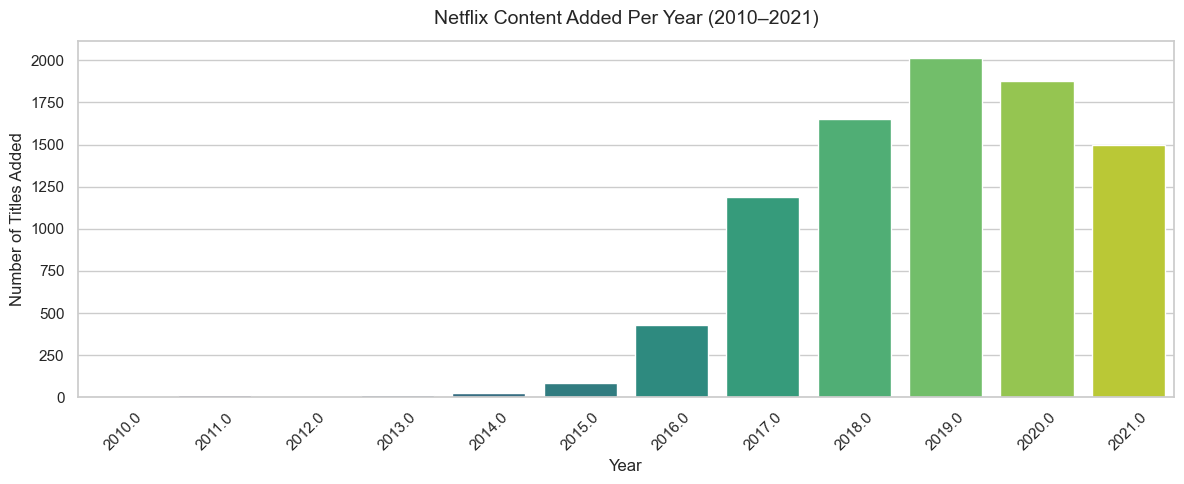

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
recent = content_per_year[content_per_year['year_added'] >= 2010]
sns.barplot(data=recent, x='year_added', y='count',
            palette='viridis', ax=ax)
ax.set_title('Netflix Content Added Per Year (2010–2021)', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nf_chart2_content_per_year.png', dpi=150)
plt.show()
# Finding: Massive spike in content additions from 2016–2019.

**Finding:** Content additions grew rapidly between 2016 and 2019, peaking around 2019. This aligns with Netflix's aggressive global expansion strategy during that period. A noticeable decline after 2019 likely reflects COVID-19 production disruptions and a strategic shift towards quality over quantity.

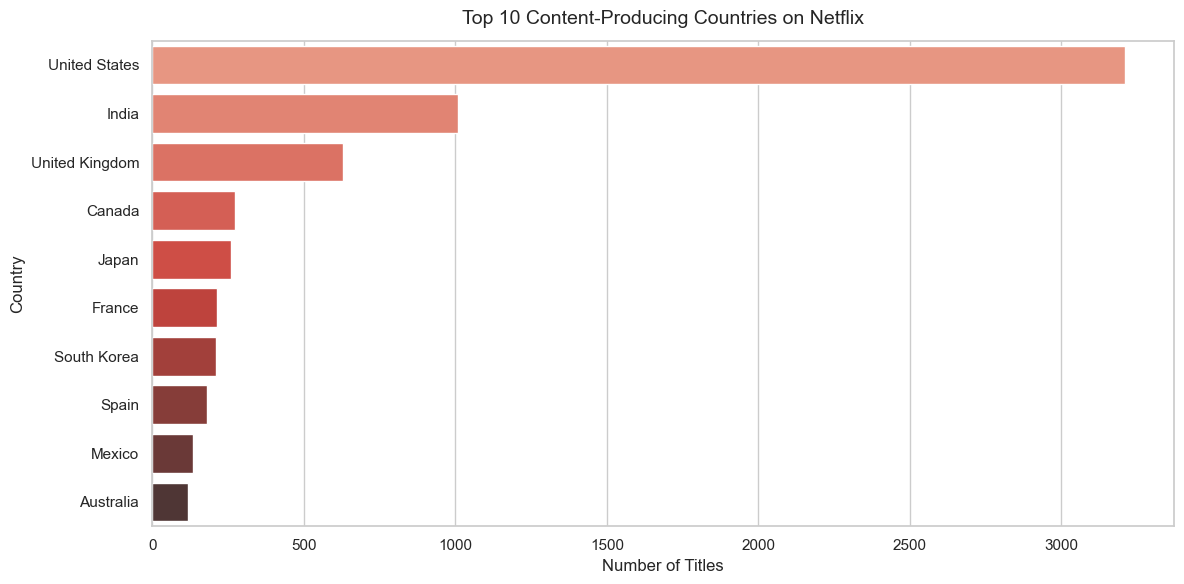

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_countries_nf, x='count', y='primary_country',
            palette='Reds_d', ax=ax)
ax.set_title('Top 10 Content-Producing Countries on Netflix', fontsize=14, pad=12)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('nf_chart3_top_countries.png', dpi=150)
plt.show()
# Finding: The United States dominates, followed by India and the United Kingdom.

**Finding:** The United States dominates Netflix content production by a significant margin, followed by India and the United Kingdom. India's strong second position reflects Netflix's major investment in Bollywood and regional Indian language content as part of its Asia-Pacific growth strategy.

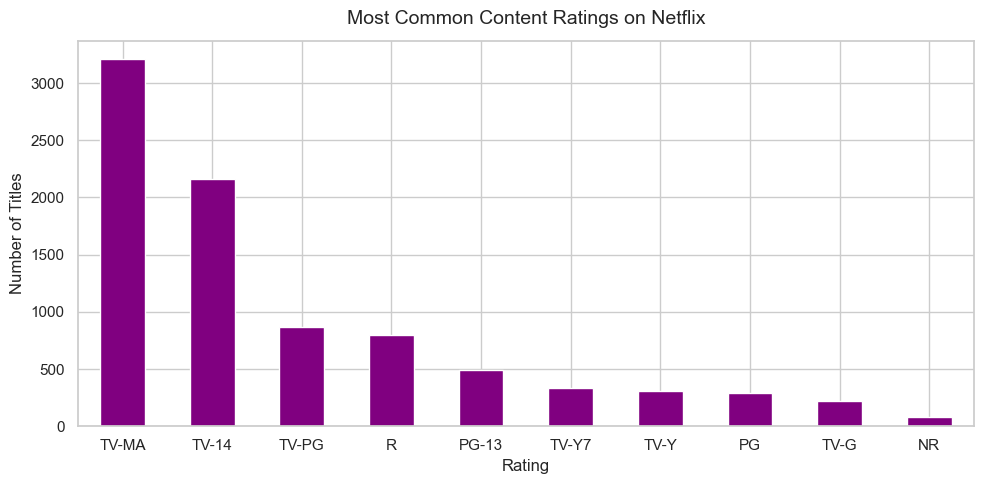

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
rating_dist.head(10).plot(kind='bar', color='purple',
                           edgecolor='white', ax=ax)
ax.set_title('Most Common Content Ratings on Netflix', fontsize=14, pad=12)
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('nf_chart4_ratings.png', dpi=150)
plt.show()
# Finding: TV-MA and TV-14 are the most common ratings, indicating mature content dominates.

**Finding:** TV-MA (Mature Audiences) and TV-14 are the two most common ratings, confirming that the majority of Netflix content targets adult and teenage viewers. Family and children's content (G, PG, TV-Y) represents a much smaller portion of the library, suggesting a potential gap Netflix could explore.

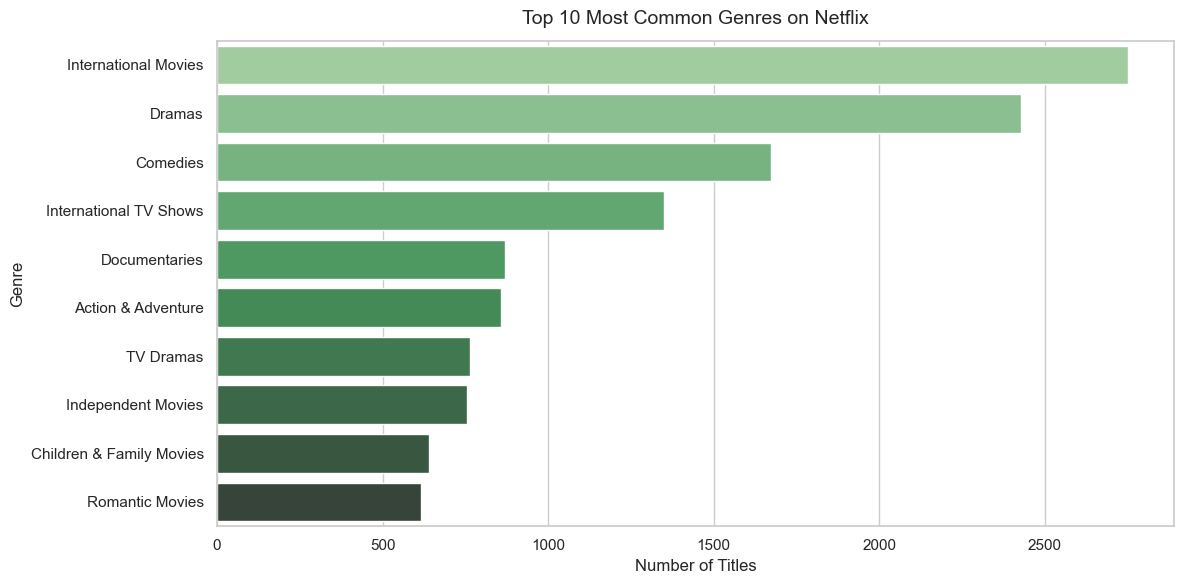

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_genres, x='count', y='genre',
            palette='Greens_d', ax=ax)
ax.set_title('Top 10 Most Common Genres on Netflix', fontsize=14, pad=12)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('nf_chart5_genres.png', dpi=150)
plt.show()
# Finding: International Movies and Dramas are the most common genres

**Finding:** International Movies and Dramas are the most represented genres on Netflix, followed by Comedies and Documentaries. The dominance of International Movies confirms that Netflix actively sources content from non-English speaking countries to serve its global subscriber base.

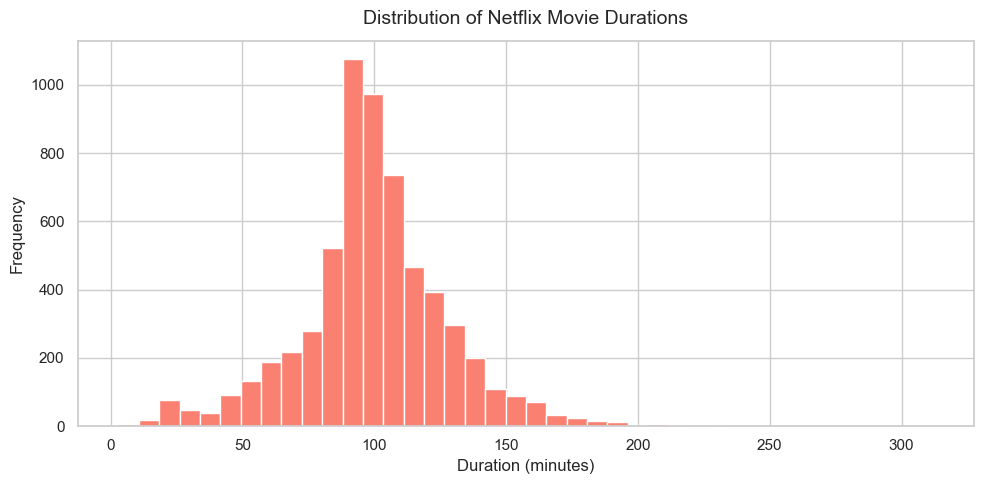

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
df_nf[df_nf['type'] == 'Movie']['duration_min'].dropna().hist(
    bins=40, color='salmon', edgecolor='white', ax=ax
)
ax.set_title('Distribution of Netflix Movie Durations', fontsize=14, pad=12)
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('nf_chart6_movie_duration.png', dpi=150)
plt.show()
# Finding: Most movies are 80–120 minutes. Few outliers beyond 200 minutes.

#### Chart 6: Movie Duration Distribution — Histogram
This histogram shows the spread of movie durations in minutes, helping us understand the typical length of films on Netflix and identify any unusual outliers.

###  Key Insights

The following insights are drawn directly from the cleaned data and supported by the visualisations produced in Task 4.

---

**Insight 1: Netflix is a Movie-first platform — but TV Shows are catching up**
Movies make up ~70% of all titles, however TV Show additions have grown steadily since 2015. As Netflix shifts towards original series to retain subscribers, this gap is likely to narrow further in coming years. *(Supported by Chart 1 & Chart 2)*

---

**Insight 2: Content growth peaked in 2019 and has since slowed**
Netflix added the most content between 2016 and 2019 during its peak global expansion phase. The slowdown post-2019 reflects a combination of COVID-19 production delays and a strategic pivot away from mass content licensing towards fewer, higher-quality original productions. *(Supported by Chart 2)*

---

**Insight 3: The US and India dominate content supply**
The United States produces the largest share of Netflix content by a wide margin. India ranks second, reflecting Netflix's deliberate investment in Bollywood and regional language content to capture the South Asian market — one of the fastest growing streaming audiences globally. *(Supported by Chart 3)*

---

**Insight 4: Netflix primarily targets adult audiences**
TV-MA and TV-14 are the dominant ratings across the library, indicating Netflix's content strategy is heavily skewed toward mature viewers. Children's and family content (G, PG, TV-G) is significantly underrepresented, which may represent an opportunity for growth in the family entertainment segment. *(Supported by Chart 4)*

---

**Insight 5: International content is Netflix's biggest genre**
International Movies top the genre list, ahead of Dramas and Comedies. This reflects Netflix's core strategy of investing in local-language content across multiple regions — from Korean dramas to Spanish thrillers — to appeal to diverse global audiences rather than relying solely on English-language productions. *(Supported by Chart 5)*

In [26]:
df_nf.to_csv('netflix_cleaned.csv', index=False)
print("Saved: netflix_cleaned.csv")

Saved: netflix_cleaned.csv


In [27]:
print("=== FINAL SUMMARY ===")
print(f"Netflix clean shape: {df_nf.shape}")
print("Netflix columns:", df_nf.columns.tolist())

print("\nNetflix sample:")
display(df_nf.head(3))

=== FINAL SUMMARY ===
Netflix clean shape: (8807, 16)
Netflix columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'date_added_clean', 'year_added', 'duration_min', 'primary_country']

Netflix sample:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_clean,year_added,duration_min,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,2021.00,90.00,United States
1,s2,Tv Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021.00,NaN,South Africa
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,2021.00,NaN,Unknown


---
## One-Page Summary Report — Netflix Dataset
---

###  Cleaning Challenges Encountered

**Missing Values**
The most significant challenge was the `director` column, which was missing in ~30% of rows. This is expected in streaming datasets as many older films and documentaries do not have a credited director. Similarly, `cast` (~10% missing) and `country` (~7% missing) had notable gaps that could not be reliably inferred. All three were filled with descriptive placeholders — *"Not Available"* and *"Unknown"* — to retain the rows for analysis without introducing false data.

**Date & Duration Formatting**
The `date_added` column was stored as a plain string rather than a datetime object, requiring conversion and extraction of a `year_added` column for trend analysis. The `duration` column mixed formats — Movies used minutes ("90 min") while TV Shows used seasons ("2 Seasons") — making a standard extraction approach fail. A custom `.apply()` function was used to correctly extract numeric durations for Movies only.

**Multi-Value Country Field**
Several titles listed more than one country separated by commas. A `primary_country` column was created using the first listed value to enable reliable country-level grouping.

---

### 🔍 Key EDA Findings

| Area | Finding |
|---|---|
| Content Split | ~70% Movies, ~30% TV Shows |
| Growth Peak | Most content added in 2018–2019 |
| Top Producer | United States, followed by India |
| Dominant Rating | TV-MA and TV-14 |
| Top Genre | International Movies and Dramas |
| Avg Movie Length | 90–100 minutes |

---

### 💡 Top Insights

**1. Netflix is Movie-heavy but TV Shows are rising**
Movies dominate the library at ~70%, but TV Show additions have grown steadily since 2015 — signalling Netflix's increasing focus on original series to retain long-term subscribers.

**2. Content expansion peaked in 2019 and has slowed**
Netflix added titles most aggressively between 2016 and 2019. The post-2019 slowdown reflects COVID-19 production disruptions and a deliberate strategic shift from volume licensing to investing in fewer, higher-quality originals.

**3. The US leads but India is closing the gap**
While the United States produces the most Netflix content by far, India's strong second-place ranking reflects Netflix's targeted investment in Bollywood and regional language content — a key move to capture Asia-Pacific's rapidly growing streaming audience.

**4. Mature content dominates — family content is underserved**
TV-MA and TV-14 are the top two ratings, confirming Netflix's primary focus on adult and teenage audiences. G and PG-rated family content is significantly underrepresented, presenting a potential growth opportunity in the family entertainment segment.

**5. International content is Netflix's biggest genre and strategic advantage**
International Movies rank as the most common genre — ahead of even Dramas and Comedies. This reflects Netflix's global-first content strategy, investing in Korean dramas, Spanish thrillers, and Indian films to differentiate itself from competitors and serve a diverse, multilingual audience.

---